# MedRegA cải tiến — Pipeline (bộ khung)

**Backbone:** Gemma 4 E4B · **Trục chính:** Hướng 1 — selective prediction / abstention (“dạy AI biết khi nào nên im lặng”).

> Đây là bộ khung (sườn) — chỉ có các section. Code điền sau ở từng ô trống.
> Kế hoạch chi tiết: `../cai_tien/ke_hoach_cac_buoc.md`

## 0. Thiết lập môi trường
Kiểm tra GPU/VRAM (nvidia-smi, torch.cuda), cài thư viện cần thiết.

In [3]:
# === [Chạy đầu tiên] Dọn VRAM: giết kernel "ma" còn ôm GPU sau restart ===
import os, subprocess, torch
if torch.cuda.is_available():
    torch.cuda.init(); _ = torch.zeros(1, device="cuda")   # chạm GPU để kernel hiện tại hiện trong nvidia-smi
my_pid = os.getpid()
raw = subprocess.run(["nvidia-smi", "--query-compute-apps=pid", "--format=csv,noheader"],
                     capture_output=True, text=True).stdout
pids = sorted({int(x) for x in raw.split() if x.strip().isdigit()})
print("PID kernel HIỆN TẠI (giữ):", my_pid, "| PID đang dùng GPU:", pids)
if my_pid in pids:
    ma = [p for p in pids if p != my_pid]
    for p in ma:
        os.system(f"kill -9 {p}"); print("  -> đã giết kernel ma:", p)
    print("Sạch." if ma else "Không có kernel ma nào.")
else:
    print("[THẬN TRỌNG] Không thấy PID hiện tại trong list -> KHÔNG tự kill (kill tay nếu chắc).")

PID kernel HIỆN TẠI (giữ): 50825 | PID đang dùng GPU: [35987, 50825]
  -> đã giết kernel ma: 35987
Sạch.


In [1]:
!nvidia-smi
import torch
print("CUDA:", torch.cuda.is_available())

Thu Jun 25 16:30:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   76C    P0             36W /   72W |   15630MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# === Cài thư viện thiếu trên Colab (chạy 1 lần đầu session) ===
# bitsandbytes: nén 4-bit | accelerate: đặt model lên GPU (device_map="auto")
%pip install -q -U bitsandbytes accelerate

## 1. Import thư viện

In [4]:
import os, json, re, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

print("Import xong | CUDA:", torch.cuda.is_available())

Import xong | CUDA: True


## 2. Cấu hình (config)
MODEL_ID, đường dẫn dữ liệu, siêu tham số (N_SAMPLES, COORD_SCALE, ngưỡng IoU, seed...).

In [5]:
MODEL_ID    = "google/gemma-3n-e4b-it"   # Gemma E4B (GATED: phải đăng nhập HF + chấp nhận license). Xác minh id trên HF.
USE_MOCK    = False           # False: chạy model thật (cần GPU); True: chạy thử không cần model
DATA_DIR    = None            # sẽ được cell xử lý LiTS (Section 3) gán = data_liver
N_SAMPLES   = 5               # số lần sample đo độ nhất quán không gian
COORD_SCALE = 1000            # toạ độ box [0,1000)
IOU_CORRECT = 0.5             # ngưỡng coi là đúng
MAX_NEW_TOKENS = 64           # số token tối đa model sinh mỗi câu trả lời (box ngắn, 64 đủ)
EVAL_LIMIT  = 40              # số ảnh test chạy ở Section 9 (None = hết 125). Giảm cho nhanh.
SEED        = 0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("DEVICE:", DEVICE, "| USE_MOCK:", USE_MOCK)

DEVICE: cuda | USE_MOCK: False


## 3. Tải dữ liệu
Nạp dữ liệu vùng y khoa (ảnh + câu hỏi + box GT). Tách train / calibration / test.

In [6]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Ví dụ đường dẫn lưu/đọc data trên Drive:
import os
DRIVE_DIR = "/content/drive/MyDrive/Colab Notebooks/medrega/data"   # đổi theo ý mày
os.makedirs(DRIVE_DIR, exist_ok=True)
print("Drive đã mount. Lưu data tại:", DRIVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive đã mount. Lưu data tại: /content/drive/MyDrive/Colab Notebooks/medrega/data


In [7]:
# === Lấy data_liver (đã xử lý sẵn dưới local, 249 mẫu) từ Drive ===
# KHÔNG tải lại 50GB LiTS. Chỉ cần data_liver (~9MB: data.jsonl + images/).
# Upload trước lên Drive: My Drive/Colab Notebooks/medrega/data/data_liver.zip
import os, zipfile, glob

DATA_DIR = os.path.join(DRIVE_DIR, "data_liver")     # DRIVE_DIR từ cell mount
zip_path = os.path.join(DRIVE_DIR, "data_liver.zip")

if not os.path.exists(os.path.join(DATA_DIR, "data.jsonl")):
    if os.path.exists(zip_path):
        print("Giải nén data_liver.zip ->", DATA_DIR)
        os.makedirs(DATA_DIR, exist_ok=True)
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(DATA_DIR)
    else:
        raise FileNotFoundError(
            "Thiếu data: chưa thấy data_liver/data.jsonl lẫn data_liver.zip trong "
            + DRIVE_DIR + ". Hãy upload data_liver.zip (24MB) lên thư mục đó.")
else:
    print("Đã có data_liver trên Drive -> dùng luôn.")

n_img = len(glob.glob(os.path.join(DATA_DIR, "images", "*.png")))
n_row = sum(1 for _ in open(os.path.join(DATA_DIR, "data.jsonl"), encoding="utf-8"))
print("DATA_DIR =", DATA_DIR, "| jsonl dòng:", n_row, "| ảnh PNG:", n_img)

Đã có data_liver trên Drive -> dùng luôn.
DATA_DIR = /content/drive/MyDrive/Colab Notebooks/medrega/data/data_liver | jsonl dòng: 249 | ảnh PNG: 249


In [8]:
%pip install -q huggingface_hub
from huggingface_hub import snapshot_download
import os, glob

MEDREG_DIR = snapshot_download(repo_id="Luxuriant16/MedRegInstruct", repo_type="dataset")
print("Tải về:", MEDREG_DIR)
for p in sorted(glob.glob(os.path.join(MEDREG_DIR, "**", "*"), recursive=True))[:50]:
    if os.path.isfile(p):
        print("  ", os.path.relpath(p, MEDREG_DIR))

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Tải về: /root/.cache/huggingface/hub/datasets--Luxuriant16--MedRegInstruct/snapshots/cb87b8b92e0aefdee20484d362456d845266058d
   README.md
   test/grounded_reports_mimiccxr.jsonl
   test/region2text.jsonl
   test/text2region.jsonl
   train/region2text.jsonl
   train/text2region.jsonl


In [9]:
import json, os

for rel in ["train/text2region.jsonl", "train/region2text.jsonl", "test/grounded_reports_mimiccxr.jsonl"]:
    path = os.path.join(MEDREG_DIR, rel)
    print("=" * 70)
    print(rel)
    print("=" * 70)
    with open(path, encoding="utf-8") as f:
        for i, line in enumerate(f):
            print(json.dumps(json.loads(line), ensure_ascii=False, indent=2)[:1200])
            if i >= 0:   # in 1 mẫu/đầu file; đổi >=1 nếu muốn 2 mẫu
                break
    print()

train/text2region.jsonl
{
  "id": -1,
  "image": "SAMed2Dv1/images/mr_00--ACDC--patient019_frame01--x_0000.png",
  "width": 216,
  "height": 256,
  "conversations": [
    {
      "from": "human",
      "value": "Could you specify the corner points for a bounding box surrounding <ref>heart myocardium</ref> <ref>right ventricle</ref>?"
    },
    {
      "from": "gpt",
      "value": "<ref>heart myocardium</ref><box>[[346, 401, 596, 636]]</box>, <ref>right ventricle</ref><box>[[370, 429, 573, 612]]</box>"
    }
  ]
}

train/region2text.jsonl
{
  "id": -1,
  "image": "SAMed2Dv1/images/mr_00--ACDC--patient075_frame06--x_0001.png",
  "width": 168,
  "height": 224,
  "conversations": [
    {
      "from": "human",
      "value": "What can be visualized in the <box>[[214, 437, 392, 619]]</box> of this medical scan?"
    },
    {
      "from": "gpt",
      "value": "left ventricle"
    }
  ]
}

test/grounded_reports_mimiccxr.jsonl
{
  "id": -1,
  "image": "mimic-cxr-jpg/2.0.0/files/p10/p100461

In [10]:
# === Đọc data.jsonl + chia train/cal/test THEO BỆNH NHÂN (không lộ dữ liệu) ===
# train: để fine-tune | cal: hiệu chỉnh ngưỡng (Hướng 1) | test: đánh giá cuối.
import json, numpy as np

rows = [json.loads(l) for l in open(os.path.join(DATA_DIR, "data.jsonl"), encoding="utf-8")]

rng = np.random.default_rng(SEED)                    # SEED từ cell config (Section 2)
pids = sorted({r["patient_id"] for r in rows}); rng.shuffle(pids)
n = len(pids)
n_tr, n_ca = int(n * 0.6), int(n * 0.2)              # 60% train / 20% cal / 20% test
tr = set(pids[:n_tr]); ca = set(pids[n_tr:n_tr + n_ca])
dataset = {
    "train": [r for r in rows if r["patient_id"] in tr],
    "cal":   [r for r in rows if r["patient_id"] in ca],
    "test":  [r for r in rows if r["patient_id"] not in tr and r["patient_id"] not in ca],
}
OUT_DIR = DATA_DIR

# kiểm tra không lộ dữ liệu: 3 tập không trùng bệnh nhân
_s = {k: {r["patient_id"] for r in v} for k, v in dataset.items()}
assert not (_s["train"] & _s["cal"]) and not (_s["train"] & _s["test"]) and not (_s["cal"] & _s["test"])
print("Tổng mẫu:", len(rows),
      "| dương:", sum(r["label"] == "tumor" for r in rows),
      "| âm:", sum(r["label"] == "none" for r in rows))
print("Split (theo bệnh nhân):", {k: len(v) for k, v in dataset.items()})
print("Bệnh nhân:", {k: len(s) for k, s in _s.items()}, "-> không trùng (OK)")

Tổng mẫu: 249 | dương: 118 | âm: 131
Split (theo bệnh nhân): {'train': 150, 'cal': 47, 'test': 52}
Bệnh nhân: {'train': 78, 'cal': 26, 'test': 27} -> không trùng (OK)


## 4. Tiền xử lý dữ liệu
Chuẩn hoá toạ độ về [0,1000), dựng prompt/chỉ dẫn cho từng tác vụ, format đầu vào cho model.

In [11]:
# ============================================================
# Section 4 — Format record -> input chuẩn Gemma (chat template)
#   - human -> role "user" (ảnh + câu hỏi);  gpt -> role "model" (đáp án)
#   - ẢNH đưa qua content {"type":"image"} (KHÔNG gõ <image>); processor tự chèn token ảnh
#   - <ref>/<box> giữ nguyên dạng text (Gemma học như chữ)
#   - INFERENCE: chỉ user + add_generation_prompt=True
#   - TRAIN: user + model, rồi MASK loss chỉ trên token đáp án
#   * Các hàm dưới cần `processor` (nạp ở Section 5) -> chỉ định nghĩa, gọi sau.
# ============================================================
from PIL import Image
import os

# Prompt ÉP định dạng + thang đo (vì Gemma trần không tự biết format MedRegA).
INSTRUCT_PROMPT = """You are a medical imaging assistant. This abdominal CT image may or may not contain a liver tumor (an abnormal mass or lesion inside the liver). Examine the liver region carefully.
Coordinate system: treat the image as a 1000x1000 grid. (0,0) is the TOP-LEFT corner and (1000,1000) is the BOTTOM-RIGHT corner. All coordinates are integers from 0 to 1000.
Respond with EXACTLY ONE of these three options and nothing else:
1. If you are CONFIDENT a tumor is present: <ref>liver tumor</ref><box>[[x1, y1, x2, y2]]</box>
2. If you are CONFIDENT there is no tumor: No liver tumor is found.
3. If you are genuinely UNSURE whether a tumor is present: Uncertain."""

def load_image(rec, root=None):
    """Mở ảnh PIL từ image_path (tương đối so với DATA_DIR/OUT_DIR)."""
    root = root or globals().get("DATA_DIR") or globals().get("OUT_DIR") or "."
    path = rec["image_path"]
    if not os.path.isabs(path):
        path = os.path.join(root, path)
    return Image.open(path).convert("RGB")

def to_messages(rec, with_answer):
    """record -> messages chuẩn Gemma. human->user, gpt->model.
       Ảnh qua content type=image; câu hỏi dùng INSTRUCT_PROMPT (ép format)."""
    msgs = [{"role": "user", "content": [
        {"type": "image", "image": load_image(rec)},
        {"type": "text",  "text": INSTRUCT_PROMPT},   # prompt ép [x1,y1,x2,y2] thang [0,1000)
    ]}]
    if with_answer:
        answer = rec["conversations"][-1]["value"]      # đáp án gpt (có <box> hoặc "No ...")
        msgs.append({"role": "model", "content": [{"type": "text", "text": answer}]})
    return msgs

def build_infer_inputs(rec, processor, device=None):
    """Input cho INFERENCE (chưa có đáp án; model sẽ sinh tiếp)."""
    inputs = processor.apply_chat_template(
        to_messages(rec, with_answer=False),
        add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt")
    return inputs.to(device) if device else inputs

def build_train_example(rec, processor):
    """(input_ids, labels) cho TRAIN: loss CHỈ tính trên token đáp án.
       labels = input_ids, nhưng phần prompt (user+ảnh) set = -100 (bỏ qua loss)."""
    full = processor.apply_chat_template(
        to_messages(rec, with_answer=True),
        add_generation_prompt=False, tokenize=True,
        return_dict=True, return_tensors="pt")
    prompt = processor.apply_chat_template(
        to_messages(rec, with_answer=False),
        add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt")
    labels = full["input_ids"].clone()
    plen = prompt["input_ids"].shape[1]                 # độ dài phần prompt
    labels[:, :plen] = -100                             # che prompt -> không tính loss
    out = dict(full); out["labels"] = labels
    return out

print("Đã định nghĩa: INSTRUCT_PROMPT, load_image, to_messages, build_infer_inputs, build_train_example")
print("(gọi sau khi nạp `processor` ở Section 5)")

# --- (tùy chọn) thử nhanh khi đã có processor + dataset thật ---
if (not USE_MOCK) and ("processor" in globals()) and ("dataset" in globals()) and dataset.get("test"):
    _ex = build_infer_inputs(dataset["test"][0], processor)
    print("Thử build_infer_inputs OK | keys:", list(_ex.keys()),
          "| input_ids shape:", tuple(_ex["input_ids"].shape))

Đã định nghĩa: INSTRUCT_PROMPT, load_image, to_messages, build_infer_inputs, build_train_example
(gọi sau khi nạp `processor` ở Section 5)


## 5. Tải model (Gemma 4 E4B)
Nạp model + processor. (Tùy chọn cấu hình quantize 4-bit cho QLoRA.)

In [12]:
# === Section 5: Tải model Gemma + processor ===
# Cấu trúc:
#   /content/hf_cache          <- weights gốc (ổ LOCAL, tải lại mỗi session ~1-2 phút)
#   medrega/secrets.env        <- file chứa HF_TOKEN (trên Drive)
#   medrega/model/checkpoints  <- checkpoint sau fine-tune
# Gemma GATED: nhớ bấm "Agree" tại huggingface.co/google/gemma-3n-e4b-it (1 lần).
import os, torch

# bf16 (16-bit): chạy NHANH, hợp INFERENCE Hướng 1. ~16GB VRAM (vừa L4 24GB).
# 4-bit: tiết kiệm VRAM (~6GB) nhưng sinh chữ CHẬM hơn -> chỉ bật khi train QLoRA.
LOAD_IN_4BIT = False

MEDREGA_ROOT = os.path.dirname(DRIVE_DIR.rstrip("/"))          # .../medrega
HF_CACHE = "/content/hf_cache"                                  # weights gốc (local, nhanh)
CKPT_DIR = os.path.join(MEDREGA_ROOT, "model", "checkpoints")  # checkpoint fine-tune
os.makedirs(HF_CACHE, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print("Model raw:", HF_CACHE, "| 4-bit:", LOAD_IN_4BIT)

def _read_hf_token():
    try:
        from google.colab import userdata
        t = userdata.get("HF_TOKEN")
        if t: return t
    except Exception:
        pass
    env_path = os.path.join(MEDREGA_ROOT, "secrets.env")
    if os.path.exists(env_path):
        for line in open(env_path, encoding="utf-8"):
            line = line.strip()
            if line and not line.startswith("#") and line.split("=", 1)[0].strip() == "HF_TOKEN":
                return line.split("=", 1)[1].strip().strip(chr(34)).strip(chr(39))
    return os.environ.get("HF_TOKEN")

if not USE_MOCK:
    from huggingface_hub import login
    _tok = _read_hf_token()
    if _tok:
        login(token=_tok)
        print("Đã đăng nhập HF (token:", _tok[:6] + "...).")
    else:
        print("[CẢNH BÁO] Không tìm thấy HF_TOKEN -> tải Gemma sẽ lỗi 401.")

    DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    print("dtype:", DTYPE)

    processor = AutoProcessor.from_pretrained(MODEL_ID, cache_dir=HF_CACHE)
    if LOAD_IN_4BIT:
        bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=DTYPE, bnb_4bit_use_double_quant=True)
        model = AutoModelForImageTextToText.from_pretrained(
            MODEL_ID, cache_dir=HF_CACHE, quantization_config=bnb,
            torch_dtype=DTYPE, device_map={"": 0})
    else:
        model = AutoModelForImageTextToText.from_pretrained(
            MODEL_ID, cache_dir=HF_CACHE,
            torch_dtype=DTYPE, device_map={"": 0})    # bf16, ép lên GPU 0
    model.eval()
    print("Đã tải model:", MODEL_ID, "| device:", next(model.parameters()).device,
          "| VRAM:", round(torch.cuda.memory_allocated()/1e9, 1), "GB")
else:
    processor, model = None, None
    print("USE_MOCK=True -> bỏ qua tải model (dùng Mock ở Section 8).")

Model raw: /content/hf_cache | 4-bit: False
Đã đăng nhập HF (token: hf_vVw...).
dtype: torch.bfloat16


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/1631 [00:00<?, ?it/s]

Đã tải model: google/gemma-3n-e4b-it | device: cuda:0 | VRAM: 15.6 GB


## 6. Hàm tiện ích
Đọc box từ text model sinh ra (parse) + tính IoU.

In [13]:
# === Section 6: Hàm tiện ích — parse_box + IoU ===
import re

def parse_box(text):
    """Đọc box từ text model -> [x1,y1,x2,y2]. None nếu model nói không có u / không có số.
       Xử lý: <box>[[x1,y1,x2,y2]]</box>, json {x,y,width,height} (xywh), hoặc 4 số đầu tiên."""
    t = str(text)
    # 1) model nói KHÔNG có u (và không kèm toạ độ) -> None (đúng cho ca âm)
    neg = re.search(r"no\b.{0,30}tumor|not\s.{0,20}found|cannot provide|no .{0,20}lesion", t, re.I)
    if neg and not re.search(r'"width"|"x"\s*:|<box>', t, re.I):
        return None
    # 2) json xywh: {"x":..,"y":..,"width":..,"height":..} -> đổi sang xyxy
    m = re.search(r'"x"\s*:\s*(\d+).*?"y"\s*:\s*(\d+).*?"width"\s*:\s*(\d+).*?"height"\s*:\s*(\d+)', t, re.S | re.I)
    if m:
        x, y, w, h = map(int, m.groups())
        return [x, y, x + w, y + h]
    # 3) lấy 4 số nguyên đầu tiên (bắt cả <box>[[...]]). Giả định x1,y1,x2,y2.
    nums = re.findall(r"\d+", t)
    if len(nums) >= 4:
        x1, y1, x2, y2 = map(int, nums[:4])
        if x2 > x1 and y2 > y1:
            return [x1, y1, x2, y2]
        return [x1, y1, x1 + abs(x2), y1 + abs(y2)]   # phòng khi lỡ là xywh
    return None

def iou(b1, b2):
    """IoU giữa 2 box [x1,y1,x2,y2]. None -> 0.0."""
    if b1 is None or b2 is None:
        return 0.0
    xa, ya = max(b1[0], b2[0]), max(b1[1], b2[1])
    xb, yb = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, xb - xa) * max(0, yb - ya)
    a1 = max(0, b1[2] - b1[0]) * max(0, b1[3] - b1[1])
    a2 = max(0, b2[2] - b2[0]) * max(0, b2[3] - b2[1])
    u = a1 + a2 - inter
    return inter / u if u > 0 else 0.0

# test nhanh
assert parse_box("<ref>liver tumor</ref><box>[[10, 20, 110, 220]]</box>") == [10, 20, 110, 220]
assert parse_box('{"x": 150, "y": 150, "width": 120, "height": 100}') == [150, 150, 270, 250]
assert parse_box("No liver tumor is found.") is None
assert abs(iou([0, 0, 100, 100], [50, 50, 150, 150]) - 1/7) < 1e-6
print("parse_box + iou OK (đã test xywh + <box> + ca âm)")

parse_box + iou OK (đã test xywh + <box> + ca âm)


# Đánh giá baseline (zero-shot) + Hướng 1

Chạy Gemma chưa fine-tune: chẩn đoán model xuất gì, vẽ ảnh+box, rồi Hướng 1 (selective prediction). *(Fine-tune + demo để ở notebook riêng.)*

In [14]:
# === [Chẩn đoán] Model thực sự xuất ra gì? (5 ảnh test) ===
import torch
for rec in dataset["test"][:5]:
    inputs = build_infer_inputs(rec, processor, device=model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    raw = processor.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print("=" * 60)
    print("GT box :", rec.get("gt_box"), "| label:", rec["label"])
    print("MODEL nói:", repr(raw))
    print("Parsed :", parse_box(raw))

GT box : [355, 173, 427, 248] | label: tumor
MODEL nói: 'Uncertain.'
Parsed : None
GT box : None | label: none
MODEL nói: 'Uncertain.'
Parsed : None
GT box : [632, 449, 667, 494] | label: tumor
MODEL nói: 'Uncertain.'
Parsed : None
GT box : None | label: none
MODEL nói: 'Uncertain.'
Parsed : None
GT box : [542, 283, 625, 359] | label: tumor
MODEL nói: 'Uncertain.'
Parsed : None


[0] label=tumor | GT=[355, 173, 427, 248] | model='Uncertain.' | box=None
[1] label=tumor | GT=[632, 449, 667, 494] | model='Uncertain.' | box=None
[2] label=tumor | GT=[542, 283, 625, 359] | model='Uncertain.' | box=None
[3] label=none  | GT=None | model='Uncertain.' | box=None
[4] label=none  | GT=None | model='Uncertain.' | box=None
[5] label=none  | GT=None | model='Uncertain.' | box=None


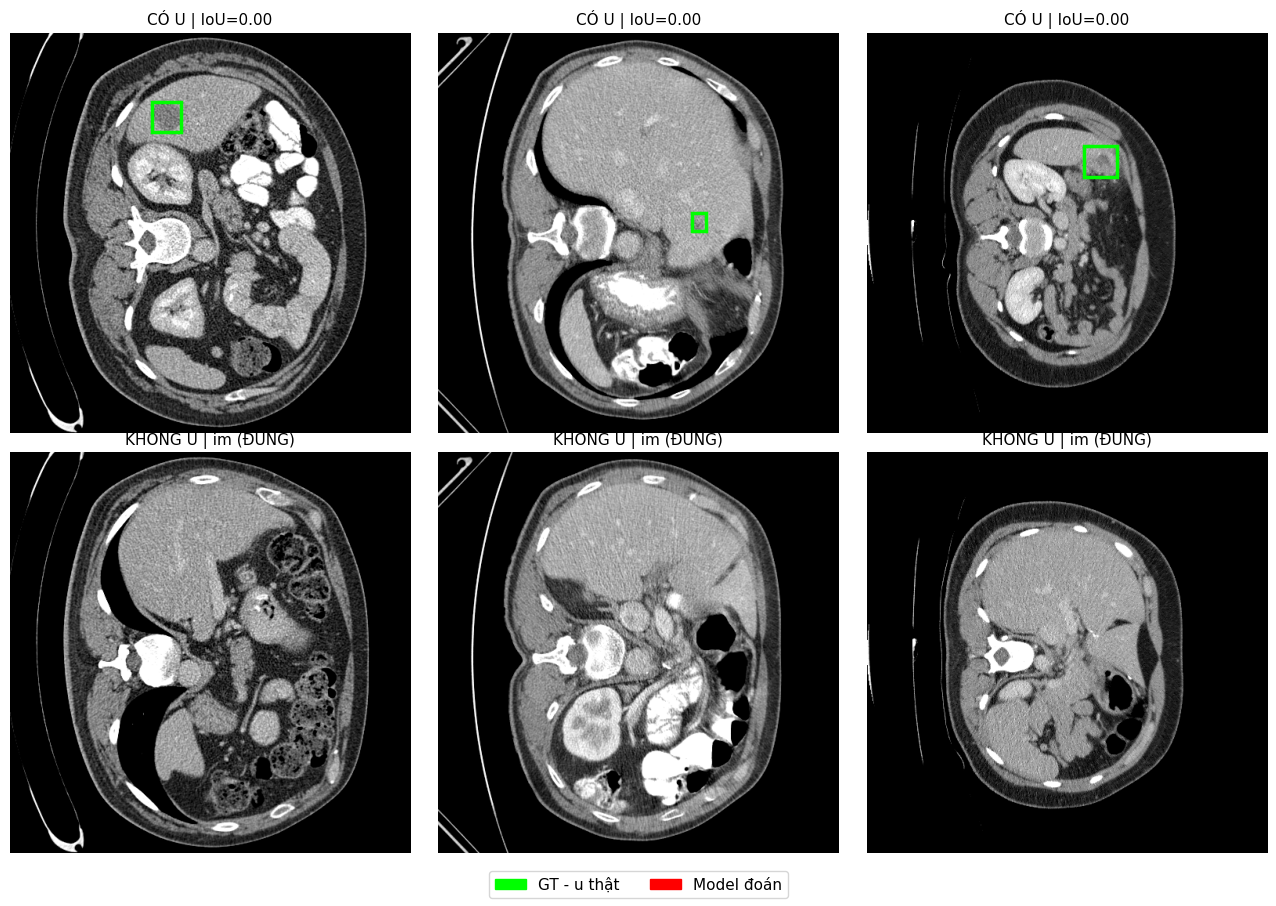

In [15]:
# === [Vẽ] Ảnh + box GT (xanh) vs model (đỏ) + in nguyên văn câu trả lời ===
import matplotlib.pyplot as plt, matplotlib.patches as patches
import matplotlib.patches as mpatches, torch

def _draw(ax, box, color, W, H):
    if box is None: return
    x1, y1, x2, y2 = (box[0]/COORD_SCALE*W, box[1]/COORD_SCALE*H,
                      box[2]/COORD_SCALE*W, box[3]/COORD_SCALE*H)
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                 linewidth=2.5, edgecolor=color, facecolor='none'))

pos = [r for r in dataset["test"] if r["label"] == "tumor"][:3]
neg = [r for r in dataset["test"] if r["label"] == "none"][:3]
samples = pos + neg
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for i, (ax, rec) in enumerate(zip(axes.flat, samples)):
    img = load_image(rec); W, H = img.size
    inputs = build_infer_inputs(rec, processor, device=model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    raw = processor.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    pred = parse_box(raw)
    print(f"[{i}] label={rec['label']:5} | GT={rec.get('gt_box')} | model={raw!r} | box={pred}")
    ax.imshow(img)
    _draw(ax, rec.get("gt_box"), "lime", W, H)
    _draw(ax, pred, "red", W, H)
    gt = rec.get("gt_box")
    title = (f"CÓ U | IoU={iou(pred, gt):.2f}" if gt is not None
             else "KHÔNG U | " + ("im (ĐÚNG)" if pred is None else "BỊA U"))
    ax.set_title(title, fontsize=11); ax.axis("off")
fig.legend(handles=[mpatches.Patch(color="lime", label="GT - u thật"),
                    mpatches.Patch(color="red",  label="Model đoán")],
           loc="lower center", ncol=2, fontsize=11)
plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

## 8. Hàm dự đoán + độ tin cậy
`predict()` (trả box + logprob token toạ độ), và 3 tín hiệu tin cậy: logprob / nhất quán không gian (sample N lần) / hỏi thẳng độ tự tin.

In [16]:
# === Section 8: predict_box + 3 tín hiệu tin cậy ===
import numpy as np, hashlib

if USE_MOCK:
    def _difficulty(rec):
        h = int(hashlib.md5(str(rec["id"]).encode()).hexdigest(), 16)
        return (h % 1000) / 1000.0
    def predict_box(rec, temperature=0.0):
        d = _difficulty(rec); gt = rec.get("gt_box") or [400, 400, 600, 600]
        jit = 1.0 if temperature > 0 else 0.4
        noise = np.random.normal(0, COORD_SCALE * (0.02 + 0.3 * d) * jit, 4)
        b = [int(np.clip(gt[i] + noise[i], 0, COORD_SCALE - 1)) for i in range(4)]
        b = [min(b[0], b[2]), min(b[1], b[3]), max(b[0], b[2]), max(b[1], b[3])]
        lp = float(np.clip(-0.1 - 2.5 * d + np.random.normal(0, 0.1), -5, 0))
        return b, lp
    def conf_self(rec):
        return float(np.clip(1.0 - _difficulty(rec) + np.random.normal(0, 0.05), 0, 1))
else:
    import torch, torch.nn.functional as F
    @torch.no_grad()
    def predict_box(rec, temperature=0.0):
        inp = build_infer_inputs(rec, processor, device=model.device)
        gen = model.generate(**inp, max_new_tokens=MAX_NEW_TOKENS,
                             do_sample=temperature > 0, temperature=max(temperature, 1e-5),
                             output_scores=True, return_dict_in_generate=True)
        new = gen.sequences[0][inp["input_ids"].shape[1]:]
        box = parse_box(processor.decode(new, skip_special_tokens=True))
        lps = [F.log_softmax(sc[0], -1)[t].item() for t, sc in zip(new, gen.scores)]
        return box, (float(np.mean(lps)) if lps else -10.0)
    @torch.no_grad()
    def conf_self(rec):
        r2 = dict(rec); r2["question"] = rec["question"] + " How confident are you from 0 to 100? Answer one number."
        inp = build_infer_inputs(r2, processor, device=model.device)
        gen = model.generate(**inp, max_new_tokens=8)
        m = re.findall(r"\d+", processor.decode(gen[0][inp["input_ids"].shape[1]:], skip_special_tokens=True))
        return min(int(m[0]), 100) / 100.0 if m else 0.5

def conf_logprob(rec):
    box, lp = predict_box(rec, temperature=0.0)
    return box, lp

def conf_spatial(rec, n=N_SAMPLES):
    boxes = [predict_box(rec, temperature=0.7)[0] for _ in range(n)]
    pair = [iou(boxes[i], boxes[j]) for i in range(len(boxes)) for j in range(i + 1, len(boxes))]
    return float(np.mean(pair)) if pair else 0.0

print("predict_box + conf_logprob/spatial/self OK | mode:", "MOCK" if USE_MOCK else "REAL")

predict_box + conf_logprob/spatial/self OK | mode: REAL


## 9. Hướng 1 — Thí nghiệm cổng (gate)
Chạy trên tập test: thu (độ tin cậy, IoU thật). Kiểm tra tương quan (Spearman) + AUROC để biết tín hiệu nào dùng được. Nếu cả 3 yếu → ghi nhận negative result.

In [17]:
# === Section 9: Thí nghiệm cổng — tín hiệu tin cậy có dự báo IoU không? ===
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

rows_eval = []
_full = dataset["test"]
_test_subset = _full[:EVAL_LIMIT] if EVAL_LIMIT else _full
print("Chay", len(_test_subset), "/", len(_full), "anh test | N_SAMPLES =", N_SAMPLES)
for rec in tqdm(_test_subset, desc="Section 9 (7 lần model/ảnh)"):
    box, lp = conf_logprob(rec)
    rows_eval.append({"rec": rec, "box": box,
                      "iou": iou(box, rec.get("gt_box")),
                      "logprob": lp, "spatial": conf_spatial(rec), "selfconf": conf_self(rec),
                      "is_pos": rec.get("gt_box") is not None})

pos = [r for r in rows_eval if r["is_pos"]]
ious = np.array([r["iou"] for r in pos])
correct = (ious >= IOU_CORRECT).astype(int)
print(f"Ca dương: {len(pos)} | IoU TB: {ious.mean():.3f} | đúng (IoU>={IOU_CORRECT}): {correct.mean():.1%}\n")
print(f"{'Tín hiệu':10s} {'Spearman':>10s} {'AUROC':>8s}")
for k in ["logprob", "spatial", "selfconf"]:
    v = np.array([r[k] for r in pos])
    rho = spearmanr(v, ious).correlation
    auc = roc_auc_score(correct, v) if len(set(correct.tolist())) > 1 else float("nan")
    print(f"{k:10s} {rho:>+10.3f} {auc:>8.3f}")

Chay 40 / 52 anh test | N_SAMPLES = 5


Section 9 (7 lần model/ảnh):   0%|          | 0/40 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Ca dương: 20 | IoU TB: 0.002 | đúng (IoU>=0.5): 0.0%

Tín hiệu     Spearman    AUROC
logprob        -0.338      nan
spatial        +0.544      nan
selfconf       -0.546      nan


## 10. Hướng 1 — Risk-coverage + Selective IoU
Sắp xếp theo độ tin cậy, chỉ trả lời phần tự tin nhất. Vẽ đường risk-coverage + tính selective IoU/F1.

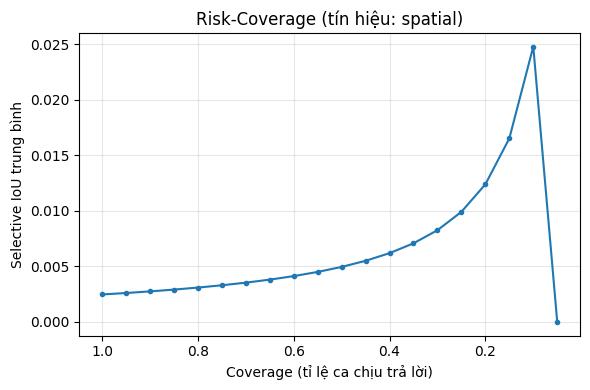

Coverage 100%: selective IoU = 0.002
Coverage 80%: selective IoU = 0.003
Coverage 60%: selective IoU = 0.004
Coverage 40%: selective IoU = 0.006


In [18]:
# === Section 10: Risk-coverage + Selective IoU ===
import matplotlib.pyplot as plt
BEST = "spatial"   # đổi theo tín hiệu có AUROC cao nhất ở Section 9
sig = np.array([r[BEST] for r in pos])
order = np.argsort(-sig)
cov, sel = [], []
for k in range(1, len(order) + 1):
    idx = order[:k]; cov.append(k / len(order)); sel.append(float(ious[idx].mean()))
plt.figure(figsize=(6, 4)); plt.plot(cov, sel, marker="o", ms=3); plt.gca().invert_xaxis()
plt.xlabel("Coverage (tỉ lệ ca chịu trả lời)"); plt.ylabel("Selective IoU trung bình")
plt.title(f"Risk-Coverage (tín hiệu: {BEST})"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
for c in [1.0, 0.8, 0.6, 0.4]:
    k = max(1, int(c * len(order)))
    print(f"Coverage {c:.0%}: selective IoU = {ious[order[:k]].mean():.3f}")

## 11. Hướng 1 — Conformal theo phương thức
Đặt ngưỡng abstain (im lặng) đảm bảo coverage guarantee, hiệu chỉnh riêng theo từng phương thức ảnh. Thêm cost-aware selective IoU (phạt nặng khi định vị bừa lúc sai).

In [19]:
# === Section 11: Conformal abstention theo phương thức + cost-aware ===
from collections import defaultdict
TARGET_COVERAGE = 0.7      # muốn trả lời ~70% ca tự tin nhất
COST_WRONG = 2.0           # phạt định vị sai gấp đôi im lặng
_sig_fn = conf_spatial     # tín hiệu dùng để abstain (đồng bộ Section 10)

def calib_threshold(records, signal_fn, target=TARGET_COVERAGE):
    """Ngưỡng = phân vị (1-target) của điểm tin cậy trên tập cal (chỉ ca dương)."""
    scores = [signal_fn(r) for r in records if r.get("gt_box") is not None]
    return float(np.quantile(scores, 1 - target)) if scores else -np.inf

by_mod = defaultdict(list)
for r in dataset["cal"]:
    by_mod[r["modality"]].append(r)
thr = {m: calib_threshold(recs, _sig_fn) for m, recs in by_mod.items()}
print("Ngưỡng tin cậy theo modality:", {m: round(t, 3) for m, t in thr.items()})

ans = sil = wrong = 0; sel_ious = []
for r in pos:
    t = thr.get(r["rec"]["modality"], -np.inf)
    if r["spatial"] >= t:                 # đủ tự tin -> trả lời
        ans += 1; sel_ious.append(r["iou"])
        if r["iou"] < IOU_CORRECT:
            wrong += 1
    else:                                  # không chắc -> IM LẶNG
        sil += 1
cost = wrong * COST_WRONG / max(len(pos), 1)   # im lặng cost 0; sai cost COST_WRONG
print(f"Trả lời: {ans} | im lặng: {sil} | sai trong số trả lời: {wrong}")
print("Selective IoU (phần trả lời): {:.3f}".format(np.mean(sel_ious)) if sel_ious else "Không trả lời ca nào")
print(f"Cost-aware (thấp = tốt): {cost:.3f}")

Ngưỡng tin cậy theo modality: {'ct_liver': 0.0}
Trả lời: 20 | im lặng: 0 | sai trong số trả lời: 20
Selective IoU (phần trả lời): 0.002
Cost-aware (thấp = tốt): 2.000


## 12. Đánh giá & lưu kết quả
Tổng hợp bảng số + biểu đồ, lưu ra file (csv/json/png) để đưa vào báo cáo.

In [20]:
# === Section 12: Đánh giá & lưu kết quả ===
import json, os
os.makedirs("outputs", exist_ok=True)
summary = {
    "mode": "MOCK" if USE_MOCK else "REAL",
    "n_test": len(rows_eval), "n_pos": len(pos),
    "iou_mean_pos": float(ious.mean()) if len(pos) else None,
    "signals": {k: {"spearman_vs_iou":
                    float(spearmanr(np.array([r[k] for r in pos]), ious).correlation) if len(pos) else None}
                for k in ["logprob", "spatial", "selfconf"]},
}
with open("outputs/huong1_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("Đã lưu outputs/huong1_summary.json")
print(json.dumps(summary, ensure_ascii=False, indent=2))

Đã lưu outputs/huong1_summary.json
{
  "mode": "REAL",
  "n_test": 40,
  "n_pos": 20,
  "iou_mean_pos": 0.002479089964154224,
  "signals": {
    "logprob": {
      "spearman_vs_iou": -0.3381787390082559
    },
    "spatial": {
      "spearman_vs_iou": 0.5439895555008006
    },
    "selfconf": {
      "spearman_vs_iou": -0.5461186812727502
    }
  }
}


## 13. (Nếu dư thời gian) Hướng 2 — Kiểm định nhân quả Regional CoT
4 nhánh đối chứng: no-box / model tự detect / box đúng (oracle) / box ngẫu nhiên. So điểm để biết AI có thật sự dùng vùng không.

In [ ]:
# TODO: 4 nhánh đối chứng + so sánh

## 14. (Nếu dư thời gian) Hướng 3 — Meta-evaluation metric
So các thước đo (RadFact / GREEN / RaTEScore / BLEU / IoU@0.5) với điểm bác sĩ chấm; kiểm tra thước nào đáng tin cho tiếng Trung / CT-MRI; probe lỗi đảo trái-phải.

In [ ]:
# TODO: meta-evaluation

## 15. Ghi chú / Kết luận
- Đây là proof-of-concept trên base nhỏ, không so kè bảng SOTA.
- Verify mọi trích dẫn SOTA trước khi đưa vào báo cáo.